# Final Model Comparison

## Objective

This notebook compares the performance of all baseline and tuned machine learning models developed for customer churn prediction. The models are evaluated using Accuracy, Precision, Recall, F1 Score, and ROC-AUC. Based on the evaluation results, the best-performing model is selected for deployment in the Customer Churn Intelligence Platform.

In [27]:
import json
import joblib
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt

## Load Model Performance Metrics

In [28]:
results_dir = Path("../results")
tuned_results_dir = Path("../results/tuned")

In [29]:
baseline_files = [
    "logistic_regression_metrics.json",
    "decision_tree_metrics.json",
    "random_forest_metrics.json",
    "xgboost_metrics.json"
]

tuned_files = [
    "logistic_regression_tuned_metrics.json",
    "decision_tree_tuned_metrics.json",
    "random_forest_tuned_metrics.json",
    "xgboost_tuned_metrics.json"
]

In [30]:
metrics = []

for file in baseline_files:
    with open(results_dir / file) as f:
        metrics.append(json.load(f))

for file in tuned_files:
    with open(tuned_results_dir / file) as f:
        metrics.append(json.load(f))

## Overall Model Performance

In [31]:
comparison_df = pd.DataFrame(metrics)
comparison_df = comparison_df.round(4)
comparison_df

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Logistic Regression,0.7967,0.6375,0.5455,0.5879,0.8305
1,Decision Tree,0.7271,0.4870,0.5000,0.4934,0.6561
2,Random Forest,0.7832,0.6237,0.4652,0.5329,0.8068
3,XGBoost,0.7861,0.6189,0.5080,0.5580,0.8047
4,Logistic Regression (Tuned),0.7974,0.6395,0.5455,0.5887,0.8304
5,Decision Tree (Tuned),0.7839,0.6577,0.3904,0.4899,0.8154
6,Random Forest (Tuned),0.7939,0.6579,0.4679,0.5469,0.8318
7,XGBoost (Tuned),0.7918,0.6494,0.4706,0.5457,0.8346


### Observation

The table summarizes the performance of all baseline and tuned machine learning models using five evaluation metrics. This comparison provides the basis for selecting the best-performing model for customer churn prediction.

In [32]:
ranking_df = comparison_df.sort_values(
    by="ROC-AUC",
    ascending=False
).reset_index(drop=True)

ranking_df.index += 1

ranking_df

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
1,XGBoost (Tuned),0.7918,0.6494,0.4706,0.5457,0.8346
2,Random Forest (Tuned),0.7939,0.6579,0.4679,0.5469,0.8318
3,Logistic Regression,0.7967,0.6375,0.5455,0.5879,0.8305
4,Logistic Regression (Tuned),0.7974,0.6395,0.5455,0.5887,0.8304
5,Decision Tree (Tuned),0.7839,0.6577,0.3904,0.4899,0.8154
6,Random Forest,0.7832,0.6237,0.4652,0.5329,0.8068
7,XGBoost,0.7861,0.6189,0.5080,0.5580,0.8047
8,Decision Tree,0.7271,0.4870,0.5000,0.4934,0.6561


### Observation

The models are ranked based on the ROC-AUC score, which is the primary evaluation metric used in this project. A higher ROC-AUC indicates a better ability to distinguish between customers who are likely to churn and those who are not.

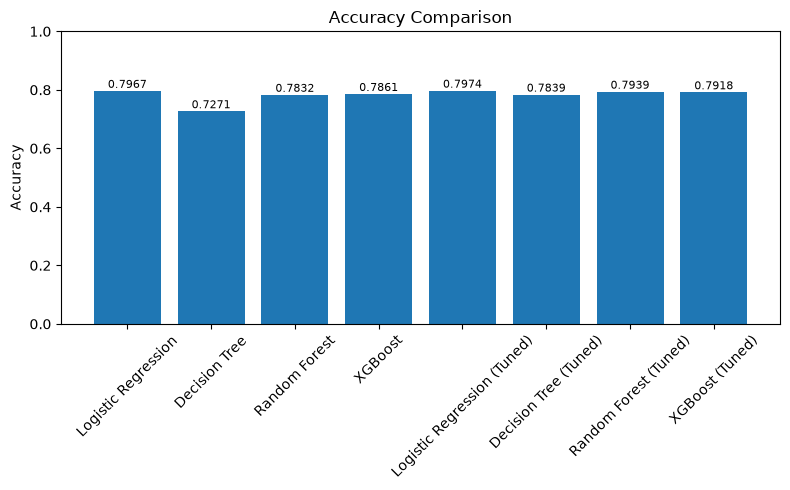

In [33]:
plt.figure(figsize=(8,5))

plt.bar(
    comparison_df["Model"],
    comparison_df["Accuracy"]
)

plt.title("Accuracy Comparison")
plt.ylabel("Accuracy")
plt.xticks(rotation=45)
plt.ylim(0,1)

for i,v in enumerate(comparison_df["Accuracy"]):
    plt.text(i,v+0.01,f"{v:.4f}",ha="center",fontsize=8)

plt.tight_layout()
plt.show()

### Observation

The tuned Logistic Regression model achieved the highest accuracy among all models. However, the difference compared with the tuned XGBoost and tuned Random Forest models is relatively small.

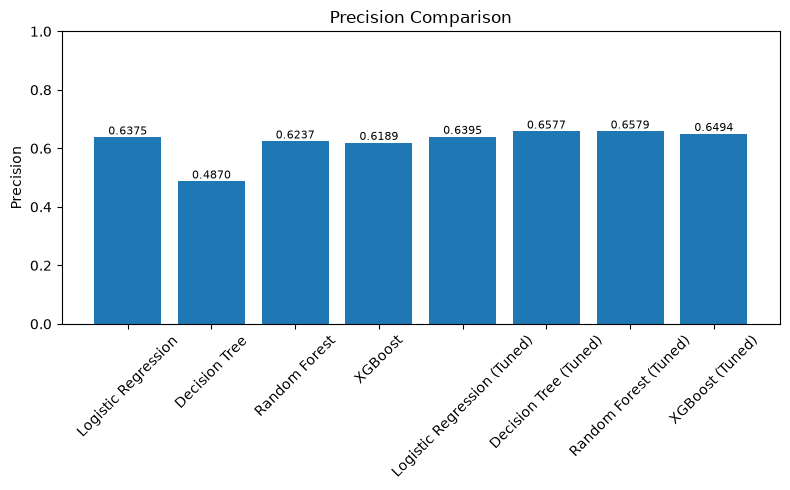

In [34]:
plt.figure(figsize=(8,5))

plt.bar(
    comparison_df["Model"],
    comparison_df["Precision"]
)

plt.title("Precision Comparison")
plt.ylabel("Precision")
plt.xticks(rotation=45)
plt.ylim(0,1)

for i,v in enumerate(comparison_df["Precision"]):
    plt.text(i,v+0.01,f"{v:.4f}",ha="center",fontsize=8)

plt.tight_layout()
plt.show()

### Observation

The tuned Random Forest model achieved the highest precision, followed closely by the tuned Decision Tree and tuned XGBoost models. Higher precision indicates fewer false positive churn predictions.

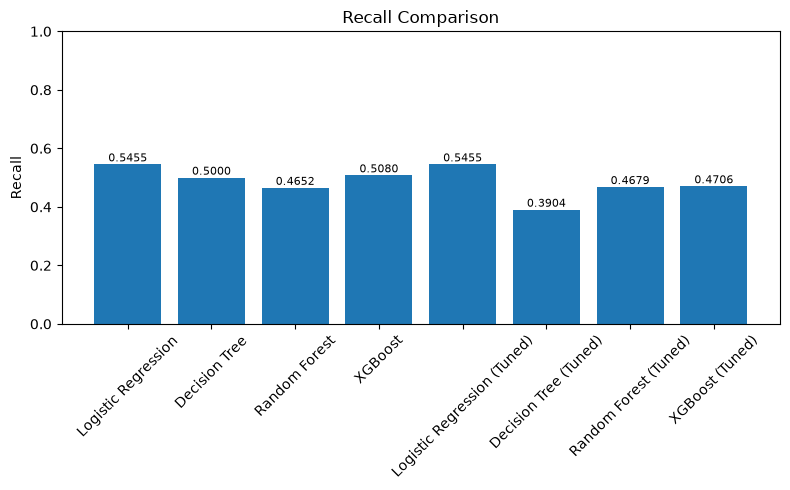

In [35]:
plt.figure(figsize=(8,5))

plt.bar(
    comparison_df["Model"],
    comparison_df["Recall"]
)

plt.title("Recall Comparison")
plt.ylabel("Recall")
plt.xticks(rotation=45)
plt.ylim(0,1)

for i,v in enumerate(comparison_df["Recall"]):
    plt.text(i,v+0.01,f"{v:.4f}",ha="center",fontsize=8)

plt.tight_layout()
plt.show()

### Observation

The Logistic Regression models achieved the highest recall, identifying the largest proportion of actual churning customers. The tuned tree-based models traded some recall for improvements in other evaluation metrics.

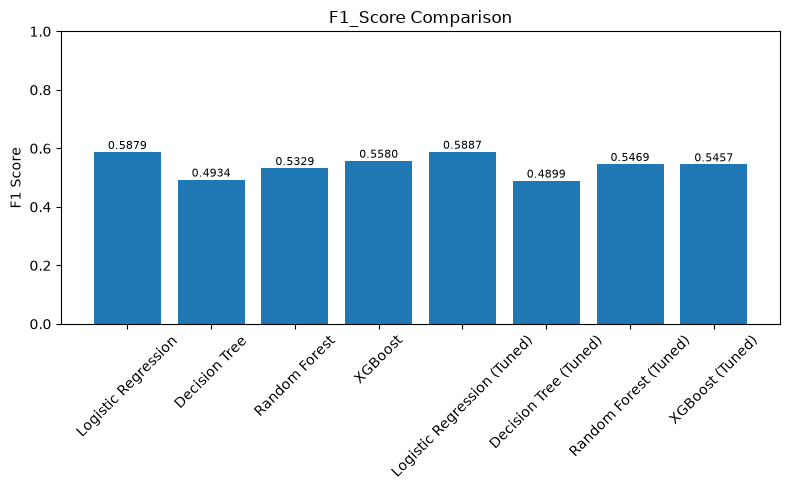

In [36]:
plt.figure(figsize=(8,5))

plt.bar(
    comparison_df["Model"],
    comparison_df["F1 Score"]
)

plt.title("F1_Score Comparison")
plt.ylabel("F1 Score")
plt.xticks(rotation=45)
plt.ylim(0,1)

for i,v in enumerate(comparison_df["F1 Score"]):
    plt.text(i,v+0.01,f"{v:.4f}",ha="center",fontsize=8)

plt.tight_layout()
plt.show()

### Observation

The tuned Logistic Regression model achieved the highest F1 Score, indicating the best balance between precision and recall among all evaluated models.

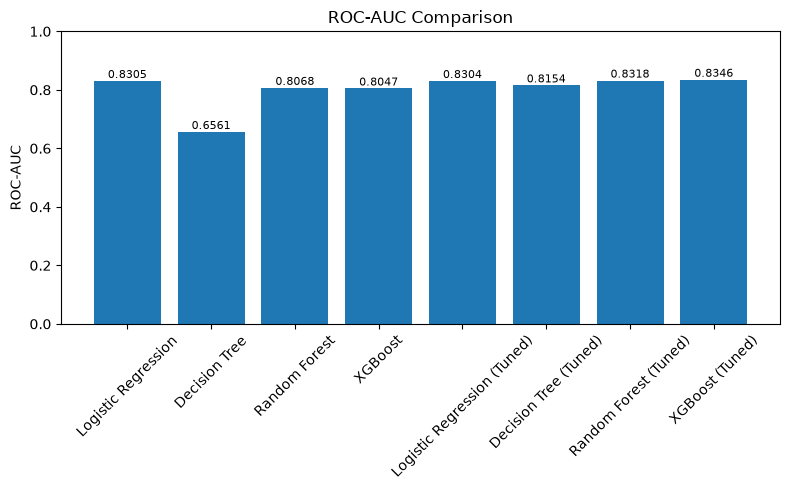

In [37]:
plt.figure(figsize=(8,5))

plt.bar(
    comparison_df["Model"],
    comparison_df["ROC-AUC"]
)

plt.title("ROC-AUC Comparison")
plt.ylabel("ROC-AUC")
plt.xticks(rotation=45)
plt.ylim(0,1)

for i,v in enumerate(comparison_df["ROC-AUC"]):
    plt.text(i,v+0.01,f"{v:.4f}",ha="center",fontsize=8)

plt.tight_layout()
plt.show()

### Observation

The tuned XGBoost model achieved the highest ROC-AUC score, followed by the tuned Random Forest model. Since ROC-AUC is the primary evaluation metric for this project, the tuned XGBoost model demonstrates the strongest overall capability to distinguish churning customers from non-churning customers.

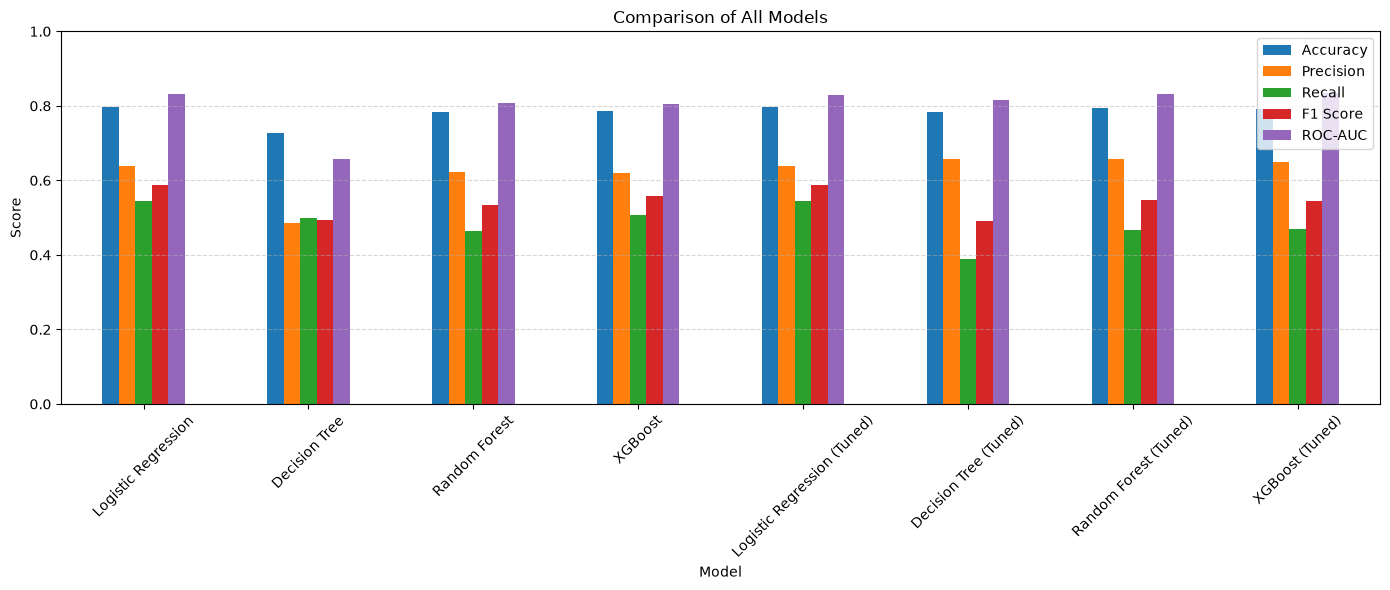

In [38]:
metrics = [
    "Accuracy",
    "Precision",
    "Recall",
    "F1 Score",
    "ROC-AUC"
]

comparison_plot = comparison_df.set_index("Model")[metrics]

comparison_plot.plot(
    kind="bar",
    figsize=(14,6)
)

plt.title("Comparison of All Models")
plt.ylabel("Score")
plt.xticks(rotation=45)
plt.ylim(0,1)

plt.grid(axis="y",linestyle="--",alpha=0.5)

plt.tight_layout()

plt.show()

### Observation

The combined comparison chart provides an overall view of model performance across all evaluation metrics. Hyperparameter tuning improved the performance of most models, with the tuned XGBoost model achieving the highest overall ROC-AUC.

# Final Model Selection

Among the eight evaluated models, the **Tuned XGBoost** model achieved the highest ROC-AUC score (**0.8346**), indicating the strongest ability to distinguish between churning and non-churning customers.

Although the tuned Logistic Regression model achieved the highest accuracy and F1 Score, the improvement in accuracy was marginal compared with the tuned XGBoost model. Since customer churn prediction is an imbalanced classification problem and ROC-AUC was selected as the primary evaluation metric, the tuned XGBoost model provides better overall ranking performance.

Therefore, the **Tuned XGBoost model** is selected as the final model for deployment in the Customer Churn Intelligence Platform.

## Save Final Model

In [39]:
models_dir = Path("../models")
tuned_models_dir = models_dir / "tuned"

In [40]:
best_model = joblib.load(
    tuned_models_dir / "xgboost_tuned.pkl"
)

In [41]:
joblib.dump(
    best_model,
    models_dir / "best_model.pkl"
)

['..\\models\\best_model.pkl']

# Conclusion

A total of eight machine learning models, including baseline and tuned versions, were evaluated for customer churn prediction. Hyperparameter tuning improved the performance of most models, particularly Decision Tree, Random Forest, and XGBoost.

Among all evaluated models, the **Tuned XGBoost** model achieved the highest ROC-AUC score and demonstrated the strongest overall predictive capability. Consequently, it has been selected as the final model for deployment in the Customer Churn Intelligence Platform.

The next stage of the project focuses on **Explainable AI (SHAP)** to interpret model predictions and enhance transparency before integrating the model into the Streamlit dashboard.

# Baseline vs Tuned Performance Improvement

To evaluate the effectiveness of hyperparameter tuning, the baseline and tuned versions of each machine learning model are compared using the ROC-AUC score. This comparison highlights the improvement achieved through hyperparameter optimization.

In [43]:
baseline_df = comparison_df[
    ~comparison_df["Model"].str.contains("Tuned")
].copy()

tuned_df = comparison_df[
    comparison_df["Model"].str.contains("Tuned")
].copy()

baseline_df["Base Model"] = baseline_df["Model"]

tuned_df["Base Model"] = tuned_df["Model"].str.replace(
    " (Tuned)",
    "",
    regex=False
)

improvement_df = baseline_df.merge(
    tuned_df,
    on="Base Model",
    suffixes=("_Baseline", "_Tuned")
)

improvement_df = improvement_df[[
    "Base Model",
    "ROC-AUC_Baseline",
    "ROC-AUC_Tuned"
]]

improvement_df.rename(columns={
    "Base Model": "Model",
    "ROC-AUC_Baseline": "Baseline ROC-AUC",
    "ROC-AUC_Tuned": "Tuned ROC-AUC"
}, inplace=True)

improvement_df["Improvement"] = (
    improvement_df["Tuned ROC-AUC"] -
    improvement_df["Baseline ROC-AUC"]
).round(4)

improvement_df

,Model,Baseline ROC-AUC,Tuned ROC-AUC,Improvement
0,Logistic Regression,0.8305,0.8304,-0.0001
1,Decision Tree,0.6561,0.8154,0.1593
2,Random Forest,0.8068,0.8318,0.0250
3,XGBoost,0.8047,0.8346,0.0299


### Observation

Hyperparameter tuning improved the ROC-AUC score of most models. The Decision Tree model showed the largest improvement, while XGBoost and Random Forest also achieved noticeable gains. Logistic Regression exhibited almost no improvement, indicating that its baseline configuration was already close to optimal.

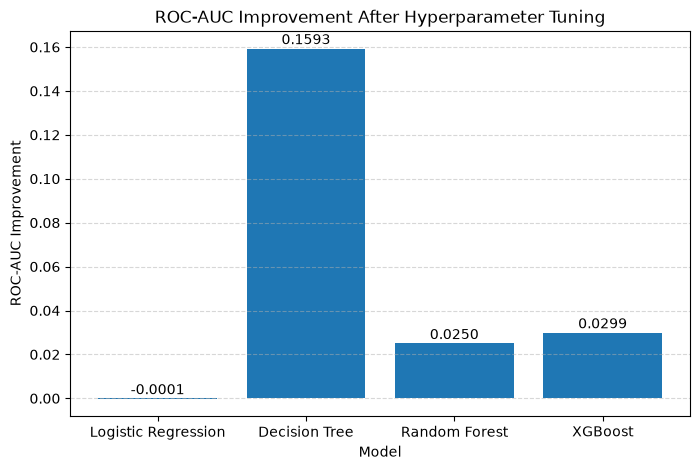

In [44]:
plt.figure(figsize=(8,5))

plt.bar(
    improvement_df["Model"],
    improvement_df["Improvement"]
)

plt.title("ROC-AUC Improvement After Hyperparameter Tuning")
plt.xlabel("Model")
plt.ylabel("ROC-AUC Improvement")

for i, value in enumerate(improvement_df["Improvement"]):
    plt.text(i, value + 0.002, f"{value:.4f}", ha="center")

plt.grid(axis="y", linestyle="--", alpha=0.5)

plt.show()

### Observation

The chart clearly demonstrates the impact of hyperparameter tuning on each model. Decision Tree achieved the greatest improvement, followed by XGBoost and Random Forest. Logistic Regression showed negligible improvement, suggesting that additional tuning offers limited benefit for this dataset.

# BEST Model

In [45]:
summary_df = pd.DataFrame({
    "Evaluation Metric":[
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score",
        "ROC-AUC"
    ],

    "Best Model":[
        comparison_df.loc[comparison_df["Accuracy"].idxmax(),"Model"],
        comparison_df.loc[comparison_df["Precision"].idxmax(),"Model"],
        comparison_df.loc[comparison_df["Recall"].idxmax(),"Model"],
        comparison_df.loc[comparison_df["F1 Score"].idxmax(),"Model"],
        comparison_df.loc[comparison_df["ROC-AUC"].idxmax(),"Model"]
    ]
})

summary_df

,Evaluation Metric,Best Model
0,Accuracy,Logistic Regression (Tuned)
1,Precision,Random Forest (Tuned)
2,Recall,Logistic Regression
3,F1 Score,Logistic Regression (Tuned)
4,ROC-AUC,XGBoost (Tuned)


### Observation

Different models performed best for different evaluation metrics. While the tuned Logistic Regression model achieved the highest Accuracy and F1 Score, the tuned Random Forest model achieved the highest Precision. The tuned XGBoost model achieved the highest ROC-AUC score, making it the preferred model for deployment.

# Why ROC-AUC was Selected as the Primary Evaluation Metric

Customer churn prediction is an imbalanced binary classification problem in which the number of non-churning customers is significantly higher than the number of churning customers.

Although Accuracy, Precision, Recall, and F1 Score provide valuable insights into model performance, ROC-AUC was selected as the primary evaluation metric because it measures the model's ability to distinguish between churning and non-churning customers across all possible classification thresholds.

A higher ROC-AUC score indicates better ranking capability, allowing businesses to adjust the decision threshold according to different customer retention strategies without retraining the model. Therefore, ROC-AUC provides a more comprehensive evaluation of model performance for customer churn prediction.

# Business Insights

The final selected model, **Tuned XGBoost**, provides the strongest overall ability to identify customers who are at risk of churning.

The model can support business decision-making by enabling organizations to:

- Identify customers with a high probability of churn.
- Prioritize customer retention campaigns.
- Optimize the allocation of marketing and support resources.
- Improve customer satisfaction through proactive engagement.
- Reduce revenue loss associated with customer attrition.

By integrating the selected model into the Customer Churn Intelligence Platform, businesses can make data-driven decisions to improve customer retention and maximize long-term profitability.